In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
!pip install -q xclim xsdba

In [3]:
# ==========================================
# 🗂  Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                    — all hyper-parameters
#   runtime.log                    — epoch logs + timing
#   chart_*_config.json            — per-chart render config
#   srunet_training_curves.png     — loss/RMSE charts
#   srunet_eval_<date>.png         — spatial eval chart
#   metrics.csv                    — final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

# ── Runtime log helper ──────────────────────────────────────────────────
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# ── Chart-save helper ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved → {path}')
    return path


Run folder (placeholder): runs/20260429_171814_lead1d
[2026-04-29 17:18:14] === Run started  (id=20260429_171814) ===
[2026-04-29 17:18:14] Run dir: runs/20260429_171814_lead1d


## Import Library

In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from xclim import sdba

/opt/conda/lib/python3.11/site-packages/xclim/sdba.py:12: UserWarning: The `xclim.sdba` module has been split into its own package `xsdba`. Users are encouraged to use `xsdba` directly. For the time being, `xclim.sdba` will import `xsdba` to allow for API compatibility. This behaviour may change in the future. For more information, see: https://xsdba.readthedocs.io/en/stable/xclim_migration_guide.html
  warnings.warn(


In [5]:
## Config
scale = 6
lead_days = 1
seed = 42
BATCH_SIZE = 16

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

# ── Refresh RUN_DIR now that lead_days is defined ──────────────────────
RUN_DIR = os.path.join('runs', f'{_run_id}_lead{lead_days}d')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# ── Persist config ──────────────────────────────────────────────────────
_config = {
    'scenario'         : 'scenario1-quantilemapping',
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'lead_days'        : lead_days,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved → {_cfg_path}')

Run folder: runs/20260429_171814_lead1d
[2026-04-29 17:18:16] Config saved → runs/20260429_171814_lead1d/config.json


In [6]:
# Reproducibility
np.random.seed(seed)

## Load Datasets

In [7]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

/tmp/ipykernel_178/2386494913.py:1: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")


## Lead Selection

In [8]:
lead_td = np.timedelta64(lead_days, "D")
ds_forecast = ds_forecast.sel(prediction_timedelta=lead_td)

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [9]:
ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


## Check Missing Value

In [10]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====
10m_u_component_of_wind        | NaNs:        768 | 0.02738%
2m_temperature                 | NaNs:        768 | 0.02738%
10m_v_component_of_wind        | NaNs:        768 | 0.02738%
total_precipitation_24hr       | NaNs:        768 | 0.02738%

==== Truth (High-res) ====
10m_u_component_of_wind        | NaNs:          0 | 0.00000%
10m_v_component_of_wind        | NaNs:          0 | 0.00000%
2m_temperature                 | NaNs:          0 | 0.00000%
total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Fill Missing Value

In [11]:
# ── Fill NaNs in ds_fc (xarray) ──────────────────────────────────
for var in ds_fc.data_vars:
    da = ds_fc[var]  # (time, longitude, latitude)
    nan_count = int(np.isnan(da.values).sum())
    if nan_count > 0:
        fill_val = float(np.nanmean(da.values))  # global channel mean
        ds_fc[var] = da.fillna(fill_val)
        print(f"  {var}: filled {nan_count} NaNs with mean={fill_val:.4f}")

assert all(not np.isnan(ds_fc[v].values).any() for v in ds_fc.data_vars), \
    "ds_fc still contains NaNs after imputation!"
print("ds_fc NaN fill complete — no NaNs remain.")

  10m_u_component_of_wind: filled 768 NaNs with mean=-1.4687
  2m_temperature: filled 768 NaNs with mean=299.7211
  10m_v_component_of_wind: filled 768 NaNs with mean=0.4035
  total_precipitation_24hr: filled 768 NaNs with mean=0.0066
ds_fc NaN fill complete — no NaNs remain.


## Temporal Allignment data

In [12]:
# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc = ds_fc.assign_coords(valid_time=valid_time)
ds_fc = ds_fc.sel(valid_time=common_times)
ds_fc = ds_fc.assign_coords(time=ds_fc.valid_time)
ds_fc = ds_fc.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc.time),
      len(ds_fc.latitude),
      len(ds_fc.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3650
Forecast time == Truth time: True
Forecast shape: 3650 24 32
Truth shape: 3650 144 192


## Data model preparation

In [13]:
# ==========================================
# 1️⃣ Spatial Interpolation (Low-res to High-res)
# ==========================================
# Use bilinear interpolation with proper boundary handling
print("Interpolating forecast to high-res grid with bilinear (boundary-aware)...")

# Create regridder with bilinear method
# extrap_method='nearest_s2d' handles corners/edges by using nearest neighbor for out-of-bounds points
regridder = xe.Regridder(
    ds_fc,
    ds_tr_aligned,
    method='bilinear',
    periodic=False,
    extrap_method='nearest_s2d',  # Use nearest neighbor extrapolation at corners/edges
    extrap_num_src_pnts=1,  # Number of source points for extrapolation
)

# Apply regridding to all variables
ds_fc_interp = regridder(ds_fc)
print(f"  → Bilinear interpolation applied to all variables")
print(f"  → Corner/edge handling: nearest neighbor extrapolation")
print(f"Interpolated forecast shape: {ds_fc_interp.dims}")

# ==========================================
# 2️⃣ Train/Val/Test Split (date-based)
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]

# Select by date windows (inclusive)
fc_train = ds_fc_interp.sel(time=slice(train_start_date, val_end_date))
fc_test  = ds_fc_interp.sel(time=slice(test_start_date, test_end_date))

tr_train = ds_tr_aligned.sel(time=slice(train_start_date, val_end_date))
tr_test  = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Safety checks
assert len(fc_train.time) > 0 and len(tr_train.time) > 0, "Empty train split"
assert len(fc_test.time) > 0 and len(tr_test.time) > 0, "Empty test split"

# Keep test_slice variable for downstream cells that use low-res test extraction
test_idx = np.where((ds_fc.time.values >= np.datetime64(test_start_date)) &
                    (ds_fc.time.values <= np.datetime64(test_end_date)))[0]
assert len(test_idx) > 0, "No test indices found in ds_fc"
test_slice = slice(int(test_idx[0]), int(test_idx[-1]) + 1)

print("\nDate-based split sizes:")
print(f"  Train : {len(fc_train.time)} ({str(fc_train.time.values[0])[:10]} → {str(fc_train.time.values[-1])[:10]})")
print(f"  Test  : {len(fc_test.time)} ({str(fc_test.time.values[0])[:10]} → {str(fc_test.time.values[-1])[:10]})")

print("\nDatasets split successfully")

Interpolating forecast to high-res grid with bilinear (boundary-aware)...


/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/opt/conda/lib/python3.11/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')


  → Bilinear interpolation applied to all variables
  → Corner/edge handling: nearest neighbor extrapolation
Interpolated forecast shape: FrozenMappingWarningOnValuesAccess({'time': 3650, 'latitude': 144, 'longitude': 192})

Date-based split sizes:
  Train : 3282 (2018-01-02 → 2022-06-30)
  Test  : 368 (2022-07-01 → 2022-12-31)

Datasets split successfully


In [14]:
# ==========================================
# Add units metadata for xclim compatibility
# ==========================================
print("\nAdding units metadata...")

# Define units for each variable
units_dict = {
    "10m_u_component_of_wind": "m s-1",
    "10m_v_component_of_wind": "m s-1",
    "2m_temperature": "K",
    "total_precipitation_24hr": "mm",
}

# Add units to all split datasets
for var in VARS:
    fc_train[var].attrs['units'] = units_dict[var]
    fc_test[var].attrs['units'] = units_dict[var]
    
    tr_train[var].attrs['units'] = units_dict[var]
    tr_test[var].attrs['units'] = units_dict[var]
    
    print(f"  {var}: {units_dict[var]}")

print("✓ Units metadata added successfully")


Adding units metadata...
  10m_u_component_of_wind: m s-1
  10m_v_component_of_wind: m s-1
  2m_temperature: K
  total_precipitation_24hr: mm
✓ Units metadata added successfully


In [15]:
# ==========================================
# 3️⃣ Quantile Mapping Training (train + val)
# ==========================================
print("\n" + "="*60)
print("Training Quantile Mapping models per variable...")
print("(QM fit uses train + val; no separate val in QM)")
print("="*60)

# Dictionary to store trained QM models
qm_models = {}

for var in VARS:
    print(f"\n[{var}] Training Quantile Mapping...")

    # Get QM training data (train + val)
    ref_train = tr_train[var]  # Reference (high-res truth)
    hist_train = fc_train[var]  # Historical (interpolated forecast)

    # Diagnostic: check unique value count
    ref_values = ref_train.values.flatten()
    hist_values = hist_train.values.flatten()
    ref_values = ref_values[~np.isnan(ref_values)]
    hist_values = hist_values[~np.isnan(hist_values)]

    n_unique_ref = len(np.unique(ref_values))
    n_unique_hist = len(np.unique(hist_values))
    print(f"  → Unique values: ref={n_unique_ref}, hist={n_unique_hist}")

    # Reduce nquantiles to avoid flat quantile regions
    # Use min of: 20, or half the unique values (safer)
    nquantiles = min(20, min(n_unique_ref, n_unique_hist) // 2)
    nquantiles = max(nquantiles, 5)  # at least 5 quantiles

    # For precipitation with many zeros, use even fewer quantiles
    if "precipitation" in var:
        nquantiles = min(10, nquantiles)  # max 10 quantiles for precipitation
        print(f"  → Using {nquantiles} quantiles (reduced for sparse precipitation)")
    else:
        print(f"  → Using {nquantiles} quantiles")

    # Use additive adjustment for all variables (more stable than multiplicative)
    print(f"  → Using EmpiricalQuantileMapping (additive adjustment)")
    QM = sdba.EmpiricalQuantileMapping.train(
        ref=ref_train,
        hist=hist_train,
        kind='+',  # additive adjustment - more stable for all variable types
        nquantiles=nquantiles,
    )

    qm_models[var] = QM
    print(f"  ✓ Trained with {len(ref_train.time)} timesteps (train+val)")

print("\n" + "="*60)
print("✓ All Quantile Mapping models trained successfully")
print("="*60)


Training Quantile Mapping models per variable...
(QM fit uses train + val; no separate val in QM)

_u_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=22719472, hist=52779367
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 3282 timesteps (train+val)

_v_component_of_wind] Training Quantile Mapping...
  → Unique values: ref=19860156, hist=54653680
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 3282 timesteps (train+val)

_temperature] Training Quantile Mapping...
  → Unique values: ref=838748, hist=684839
  → Using 20 quantiles
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 3282 timesteps (train+val)

[total_precipitation_24hr] Training Quantile Mapping...
  → Unique values: ref=18973533, hist=48492964
  → Using 10 quantiles (reduced for sparse precipitation)
  → Using EmpiricalQuantileMapping (additive adjustment)
  ✓ Trained with 3282 tim

In [16]:
# ==========================================
# 7️⃣ Apply Quantile Mapping to Test Set
# ==========================================
print("\n" + "="*60)
print("Applying Quantile Mapping to test set...")
print("="*60)

# Create a new dataset for corrected test predictions
fc_test_corrected = fc_test.copy(deep=True)

for var in VARS:
    print(f"\n[{var}] Applying QM correction to test set...")
    
    # Apply the trained QM model (use 'nearest' to avoid interpolation errors)
    corrected = qm_models[var].adjust(fc_test[var], interp='nearest')
    
    # Ensure corrected data uses the same dim order as fc_test[var]
    if tuple(corrected.dims) != tuple(fc_test[var].dims):
        corrected = corrected.transpose(*fc_test[var].dims)
    
    fc_test_corrected[var] = corrected
    
    print(f"  ✓ Corrected {len(fc_test.time)} timesteps")

print("\n" + "="*60)
print("✓ Test set corrected successfully")
print("="*60)


Applying Quantile Mapping to test set...

_u_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 368 timesteps

_v_component_of_wind] Applying QM correction to test set...
  ✓ Corrected 368 timesteps

_temperature] Applying QM correction to test set...
  ✓ Corrected 368 timesteps

[total_precipitation_24hr] Applying QM correction to test set...
  ✓ Corrected 368 timesteps

✓ Test set corrected successfully


U10 (m/s)
Mean -> Truth: -0.9969, Before: -1.2840, After: -1.0160
Std  -> Truth: 3.9638, Before: 3.9580, After: 3.9382

V10 (m/s)
Mean -> Truth: 0.5273, Before: 0.6870, After: 0.6118
Std  -> Truth: 3.3149, Before: 3.1410, After: 3.3646

T2m (K)
Mean -> Truth: 299.8646, Before: 299.6220, After: 299.7616
Std  -> Truth: 2.0980, Before: 2.0143, After: 2.0928

TP 24hr (mm)
Mean -> Truth: 0.0079, Before: 0.0084, After: 0.0079
Std  -> Truth: 0.0120, Before: 0.0092, After: 0.0102



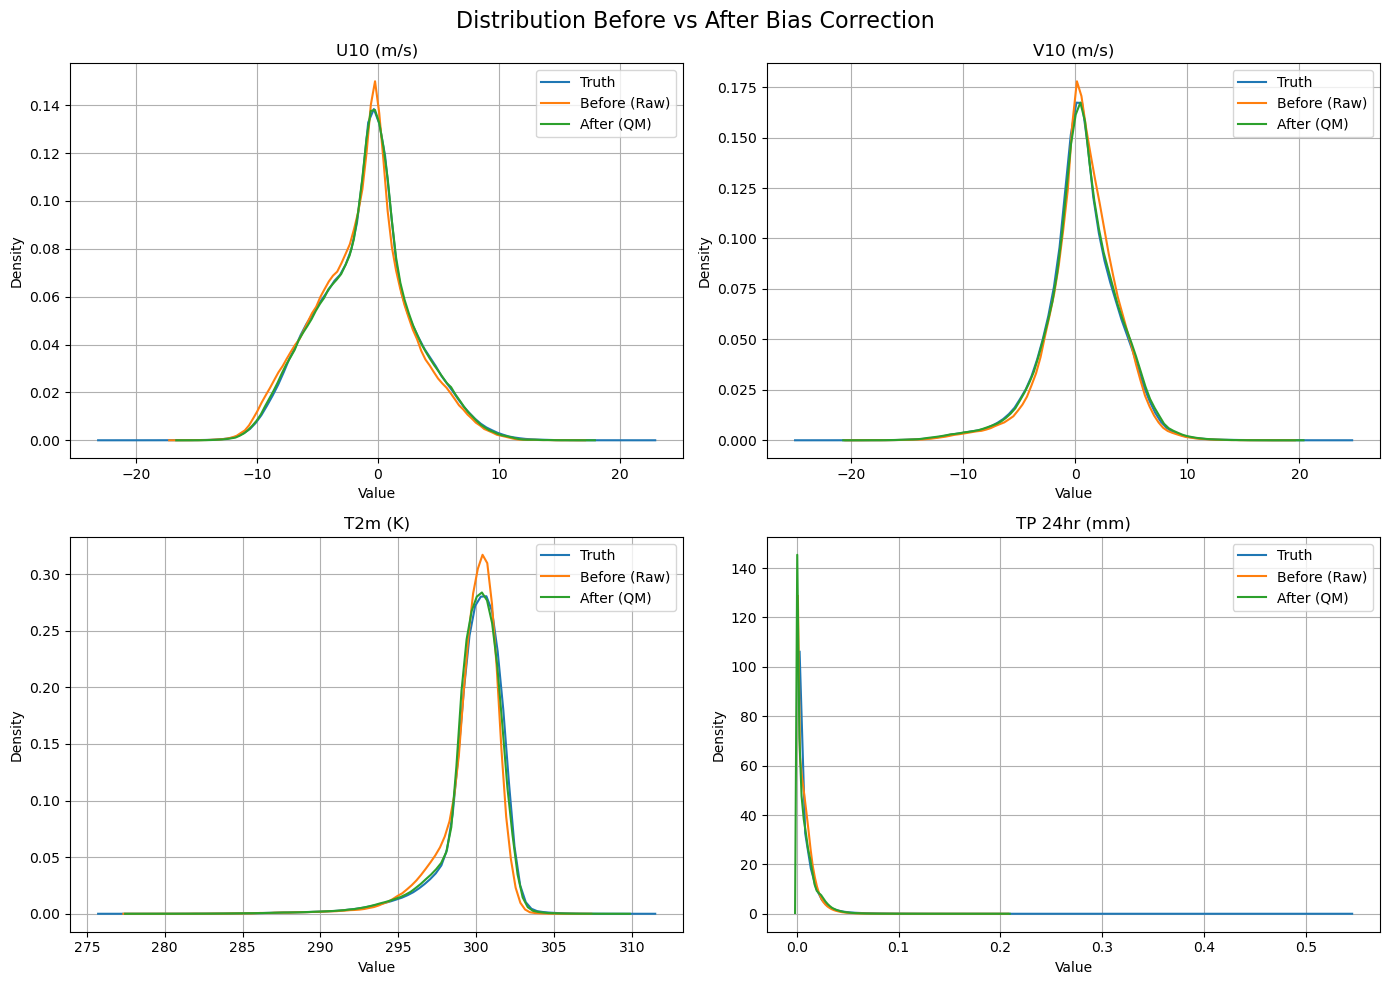

In [17]:
def plot_bias_correction_distribution_2x2(pred_raw_ds, pred_qm_ds, truth_ds, vars, labels):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()

    def plot_pdf_line(ax, data, label_name):
        hist, bins = np.histogram(data, bins=100, density=True)
        centers = 0.5 * (bins[1:] + bins[:-1])
        ax.plot(centers, hist, label=label_name)

    for ax, var, label in zip(axes, vars, labels):
        # Align first
        raw_da, truth_da = xr.align(pred_raw_ds[var], truth_ds[var], join="inner")
        qm_da, _ = xr.align(pred_qm_ds[var], truth_ds[var], join="inner")

        # Flatten after alignment
        raw = raw_da.values.reshape(-1)
        qm = qm_da.values.reshape(-1)
        truth = truth_da.values.reshape(-1)

        # Remove NaNs
        mask = ~np.isnan(raw) & ~np.isnan(qm) & ~np.isnan(truth)
        raw, qm, truth = raw[mask], qm[mask], truth[mask]

        plot_pdf_line(ax, truth, "Truth")
        plot_pdf_line(ax, raw, "Before (Raw)")
        plot_pdf_line(ax, qm, "After (QM)")

        ax.set_title(label)
        ax.set_xlabel("Value")
        ax.set_ylabel("Density")
        ax.grid(True)
        ax.legend()

        print(f"{label}")
        print(f"Mean -> Truth: {truth.mean():.4f}, Before: {raw.mean():.4f}, After: {qm.mean():.4f}")
        print(f"Std  -> Truth: {truth.std():.4f}, Before: {raw.std():.4f}, After: {qm.std():.4f}")
        print()

    fig.suptitle("Distribution Before vs After Bias Correction", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_bias_correction_distribution_2x2(
    fc_test,
    fc_test_corrected,
    tr_test,
    VARS,
    VAR_LABELS
)


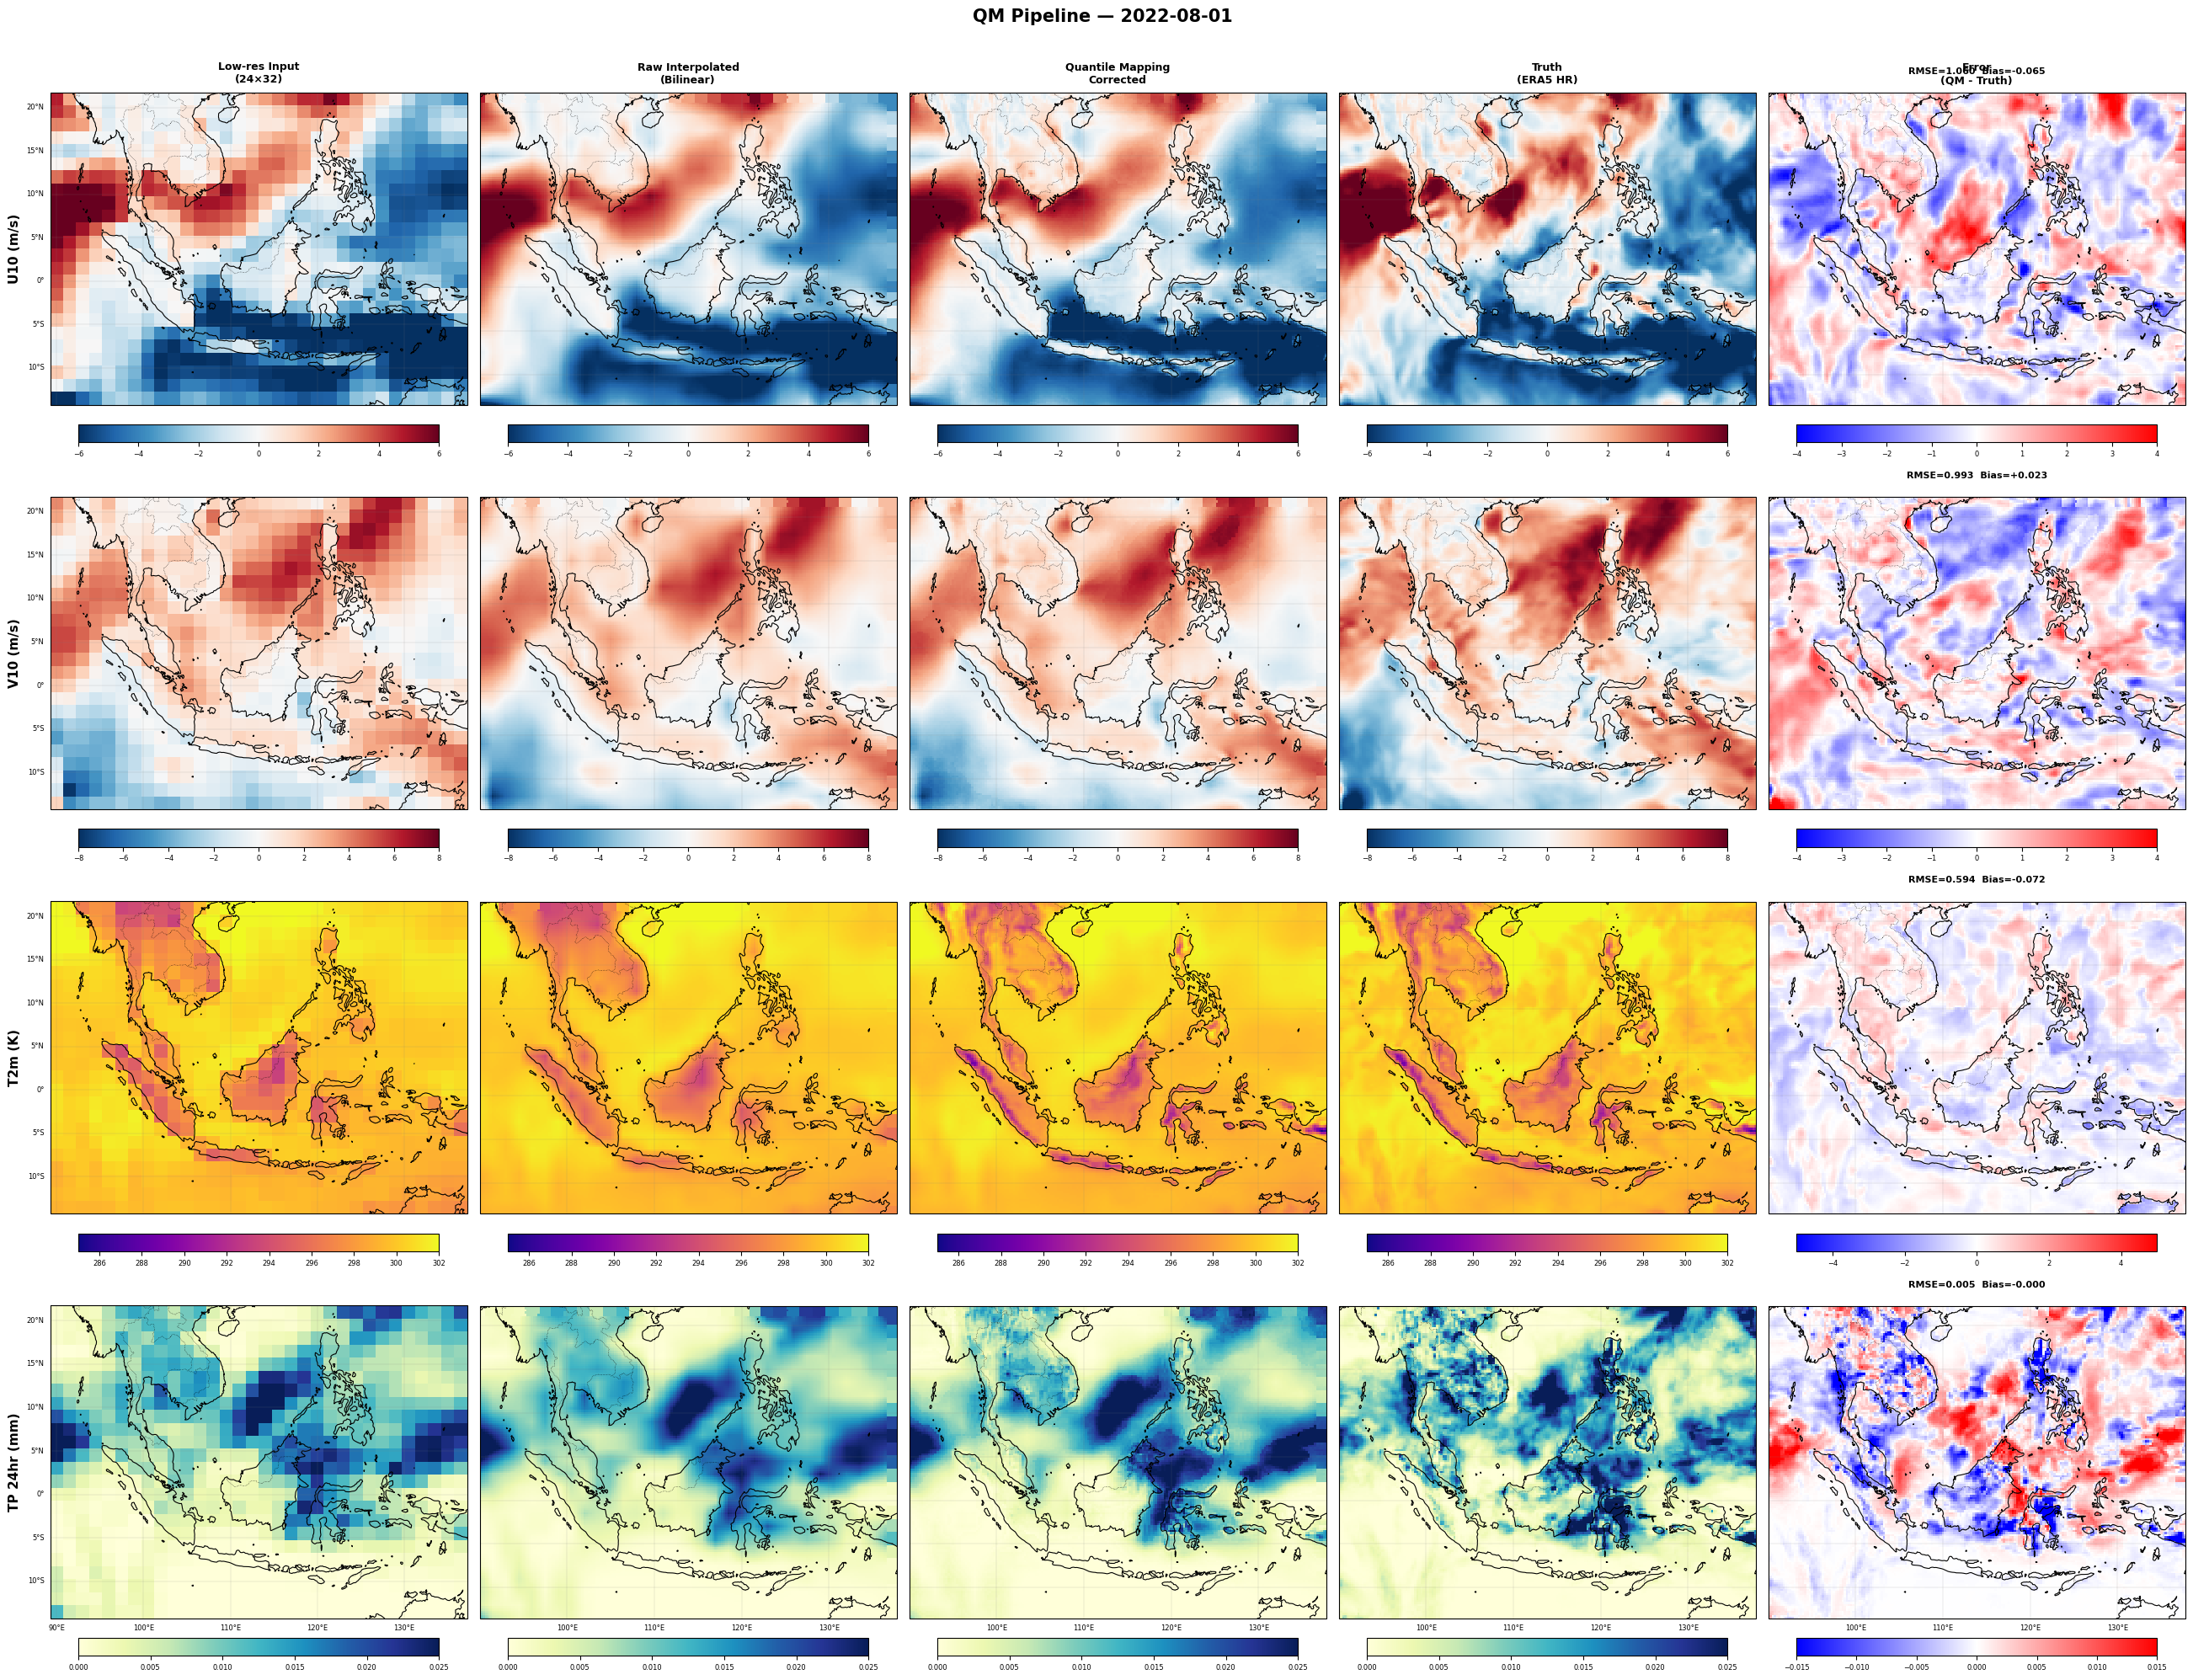


📊 Visualization shows full pipeline:
   Low-res ERA5 → Bilinear Interp → Quantile Mapping → High-res ERA5 Truth → Error


In [22]:
# ==========================================
# 🔟 Spatial Visualization - Sample Date
# ==========================================
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Config
VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# Hardcoded color ranges (adjusted based on data)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# ==============================
# Find sample in test set
# ==============================
test_times = fc_test.time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    print(f"⚠ {target_date} not found in test set.")
    print(f"Available range: {test_times[0]} → {test_times[-1]}")
    # Use first test sample instead
    idx = 0
    target_date = test_times[0]
    print(f"Using first test date: {target_date}")
else:
    idx = idx[0]

# Get sample data (high-res)
pred_raw_sample = fc_test.isel(time=idx)
pred_qm_sample = fc_test_corrected.isel(time=idx)
truth_sample = tr_test.isel(time=idx)

# Get low-res input (before interpolation)
# Find corresponding time in ds_forecast
lowres_idx = np.where(ds_fc.time.values == truth_sample.time.values)[0]
if len(lowres_idx) > 0:
    lowres_sample = ds_fc.isel(time=lowres_idx[0])
else:
    lowres_sample = ds_fc.isel(time=0)

# Get coordinates
lons_hr = truth_sample.longitude.values
lats_hr = truth_sample.latitude.values
lons_lr = lowres_sample.longitude.values
lats_lr = lowres_sample.latitude.values

# Set extent for all maps
extent = [lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()]

# ==============================
# Plot: 4 rows × 5 cols
# cols: Low-res Input | Raw Interpolated | QM Corrected | Truth | Error
# ==============================
proj = ccrs.PlateCarree()
n_vars = len(VARS)

col_titles = [
    f"Low-res Input\n({len(lats_lr)}×{len(lons_lr)})",
    "Raw Interpolated\n(Bilinear)",
    "Quantile Mapping\nCorrected",
    "Truth\n(ERA5 HR)",
    "Error\n(QM - Truth)",
]

cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 5,
    figsize=(26, 5 * n_vars),
    subplot_kw={"projection": proj},
)

# Helper function to ensure correct shape
def ensure_shape(data, target_shape):
    """Ensure data is in (lat, lon) shape"""
    if data.shape != target_shape:
        return data.T
    return data

target_shape_hr = (len(lats_hr), len(lons_hr))
target_shape_lr = (len(lats_lr), len(lons_lr))

for v_idx, var in enumerate(VARS):
    # Get low-res data
    lowres_v = ensure_shape(lowres_sample[var].values, target_shape_lr)
    
    # Get high-res data (convert DataArray to numpy) and ensure consistent shape
    raw_v = ensure_shape(pred_raw_sample[var].values, target_shape_hr)
    qm_v = ensure_shape(pred_qm_sample[var].values, target_shape_hr)
    true_v = ensure_shape(truth_sample[var].values, target_shape_hr)
    
    # Now compute error (shapes are guaranteed to match)
    err_v = qm_v - true_v
    
    cmap_f = cmaps_field[v_idx]
    
    # Hardcoded ranges
    vmin = FIELD_VMIN[v_idx]
    vmax = FIELD_VMAX[v_idx]
    elim = ERROR_LIM[v_idx]
    
    panels = [
        (lowres_v, lons_lr, lats_lr, cmap_f, vmin,  vmax, False),  # Low-res
        (raw_v,    lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # Raw interp
        (qm_v,     lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # QM
        (true_v,   lons_hr, lats_hr, cmap_f, vmin,  vmax, True),   # Truth
        (err_v,    lons_hr, lats_hr, "bwr",  -elim,  elim, True),  # Error
    ]
    
    for col, (data, lons, lats, cmap, lo, hi, is_highres) in enumerate(panels):
        ax = axes[v_idx, col]
        
        # Set extent to prevent padding issues
        if is_highres:
            ax.set_extent(extent, crs=proj)
        
        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        
        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":", zorder=2)
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0, alpha=0.3)
        ax.add_feature(cfeature.OCEAN, facecolor="lightcyan", zorder=0, alpha=0.3)
        
        # Gridlines with reduced clutter
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4,
                         x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}
        
        # Only show labels on left and bottom edges
        if col > 0:
            gl.left_labels = False
        if v_idx < n_vars - 1:
            gl.bottom_labels = False
        
        # Colorbar
        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046, shrink=0.9)
        cb.ax.tick_params(labelsize=6)
        
        # Titles
        if v_idx == 0:
            ax.set_title(col_titles[col], fontsize=9, fontweight="bold", pad=8)
        
        if col == 0:
            ax.text(-0.10, 0.5, VAR_LABELS_VIZ[v_idx], transform=ax.transAxes,
                    fontsize=11, fontweight="bold", va="center", rotation=90)
    
    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v_idx, 4].text(0.5, 1.06, f"RMSE={rmse:.3f}  Bias={bias:+.3f}",
                        transform=axes[v_idx, 4].transAxes,
                        ha='center', fontsize=8, fontweight='bold')

fig.suptitle(
    f"QM Pipeline — {str(target_date)[:10]}",
    fontsize=15, fontweight="bold", y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.995])
plt.savefig(f"pp_qm_pipeline_{str(target_date)[:10]}.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Visualization shows full pipeline:")
print(f"   Low-res ERA5 → Bilinear Interp → Quantile Mapping → High-res ERA5 Truth → Error")

In [19]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np
import xarray as xr

def _to_time_lat_lon(da: xr.DataArray) -> xr.DataArray:
    """Ensure DataArray is in (time, lat, lon) order"""
    dims = ["time", "latitude", "longitude"]
    if all(d in da.dims for d in dims):
        return da.transpose(*dims)
    return da

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

# Compute baseline RMSE on full HR grid (time-aligned only, not lat/lon inner join)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da = fc_test_lowres[v_name].transpose('time', 'latitude', 'longitude')
    truth_da_xr = tr_test_ds[v_name].transpose('time', 'latitude', 'longitude')

    # Align only along time; keep each dataset's native spatial grids
    common_time = np.intersect1d(low_da.time.values, truth_da_xr.time.values)
    low_da = low_da.sel(time=common_time)
    truth_da_xr = truth_da_xr.sel(time=common_time)

    # Baseline: bilinear upsample LR -> HR truth grid
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )

    base_v_xr = base_da.values
    true_v_xr = truth_da_xr.values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

BASELINE_EPS = 1e-8

_metrics_rows = []

for v_idx, v_name in enumerate(VARS):
    # Get aligned QM predictions and truth
    pred_da, truth_da = xr.align(fc_test_corrected[v_name], tr_test[v_name], join='inner')
    
    # Convert to (time, lat, lon) and get numpy arrays
    pred_da = _to_time_lat_lon(pred_da)
    truth_da = _to_time_lat_lon(truth_da)
    
    pred_v = pred_da.values
    true_v = truth_da.values

    # Ensure shapes match
    if pred_v.shape != true_v.shape:
        raise ValueError(
            f"Shape mismatch for {v_name}: pred={pred_v.shape}, true={true_v.shape}"
        )

    # Compute metrics grid-wise (spatial + temporal)
    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    # Aggregate across space
    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > BASELINE_EPS else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

    _metrics_rows.append({
        'variable': v_name,
        'label': label,
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'Corr': corr,
        'Baseline_RMSE': rmse_base,
        'Skill': float(skill),
    })

print("=" * 100)
print("\nSkill > 0 means QM improves over bilinear interpolation baseline.")



Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   1.1163 |   0.8462 |  -0.0191 |   0.8750 |         1.1679 |  +0.0442
V10 (m/s)          |   1.1189 |   0.8517 |  +0.0845 |   0.8612 |         1.0916 |  -0.0251
T2m (K)            |   0.6149 |   0.4814 |  -0.1026 |   0.8194 |         0.7312 |  +0.1591
TP 24hr (mm)       |   0.0065 |   0.0035 |  +0.0000 |   0.8072 |         0.0060 |  -0.0828

Skill > 0 means SRUNet improves over bilinear interpolation baseline.


In [20]:
# ── Save final test metrics to CSV ──────────────────────────────────────
import csv as _csv
import os

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved → {_csv_path}')

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\n✅ All outputs saved to: {RUN_DIR}')


[2026-04-29 17:19:44] Metrics saved → runs/20260429_171814_lead1d/metrics.csv
[2026-04-29 17:19:44] === Run finished  total_elapsed=0:01:29 ===
[2026-04-29 17:19:44] All outputs in: runs/20260429_171814_lead1d

✅ All outputs saved to: runs/20260429_171814_lead1d
